# Importando Librerias

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage

# Cargando una Imagen

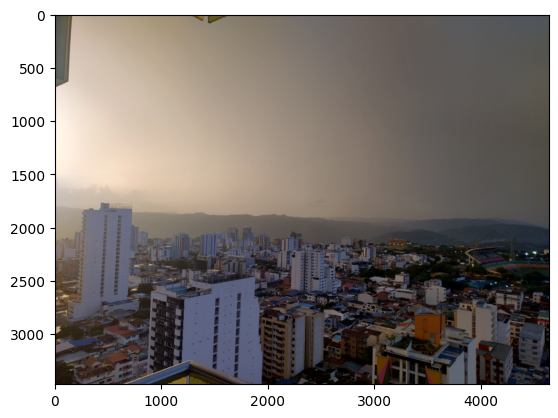

In [ ]:
image = cv.imread('/content/sample_data/1000343799.jpg')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

# Planteamiento

Se plantea el modelo Retinex:
$L = R ∘ T$

Donde $L$ representa la imagen capturada de baja luz y $R$ representa la imajen restaurada. La ecuacion establece que la imagen con baja luz es igual a multiplicar cada entrada de la imagen restaurada por cada entrada de el mapa de iluminacion $T$.

Se requiere estimar $T$, para que obtener la imagen restaurada $R = L/\hat{T}$.

La primera idea para estimar es seleccionar el mayor valor de intencidad (de los tres canales de la imagen RGB) de cada pixel.

$\hat{T}(x) ← max_{c\in RGB} L^{c}(x)$

Esto nos dice que el mapa de iluminacion es al menos el maximo valor de los tres canales.

Remplazando en la formula se añade un $ϵ$ en el denominador para evitar la division por 0.

$R = L/(max_{c} L^{c}(x)+ϵ)$

In [ ]:
def retinexMax(img,gamma,eps):
  img = img.astype(np.float32) / 255.0

  T = np.max(img, axis=2)
  T_refined = np.power(T, gamma)

  R = img / (T_refined[:,:,np.newaxis] + eps)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T_refined, R_uint8


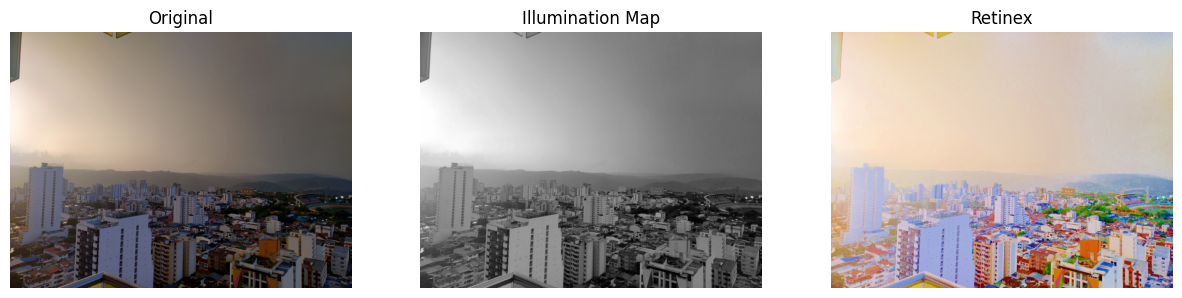

In [ ]:
gamma = 0.8
eps = 1e-6
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

T_ref, R_1 = retinexMax(image,gamma,eps)

plt.subplot(1,3,2)
plt.imshow(T_ref, cmap='gray')
plt.title("Illumination Map")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(R_1)
plt.title("Retinex")
plt.axis("off")

plt.show()

La segunda idea es trabajando con imagenes invertidas (unrealistic images) y un valor $a$ que representa la luz ambiente.

$1-L = (1-R) ∘ \hat{T} + a(1-\hat{T})$

Similar al planteamiento de la idea anterior, se estima el valor de $a(1-\hat{T})$ como el menor valor que pueda tomar $(1-L^{c})$ y asi lograr estimar $T$.

$\hat{T}(x) ← 1 - min_{c} \frac{1-L^{c}(x)}{a} = 1 - \frac{1}{a} + max_{c} \frac{L^{c}(x)}{a}$

Luego hallando la expresion para encontrar $R$

$1-L = 1∘\hat{T}-R∘\hat{T} + a1-a\hat{T} ⇒$
$R∘\hat{T} = L - 1 + a + 1∘\hat{T}-a\hat{T} ⇒ R = \frac{L - 1 + a}{\hat{T}} + 1-a$

Remplazando $\hat{T}$ en la expresion y agregando $\epsilon$ en el denominador para evitar division por 0.

$R(x) = \frac{L(x)-1+a}{1 - \frac{1}{a} + max_{c} \frac{L^{c}(x)}{a} + ϵ} + (1-a)$

Notese que al $a=1$ se tiene la expresion encontrada con la primera idea.

In [ ]:
def retinexA(img,a,gamma,eps):
  img = img.astype(np.float32) / 255.0

  T = 1-(1/a)+np.max(img, axis=2)/a
  T = np.clip(T, 0.2, 1)
  T_refined = np.power(T, gamma)

  R = (img-1+a)/ (1-(1/a)+T_refined[:,:,np.newaxis] + eps) + (1-a)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T_refined, R_uint8

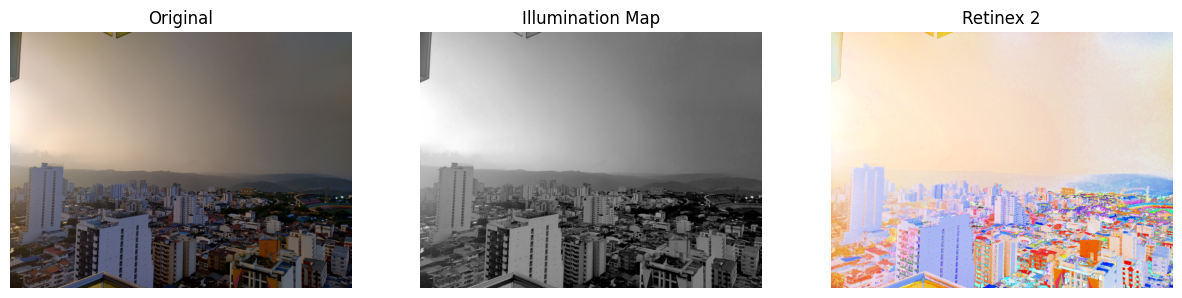

In [ ]:
a = 0.95
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

T_ref2, R_2 = retinexA(image,a,gamma,eps)

plt.subplot(1,3,2)
plt.imshow(T_ref2, cmap='gray')
plt.title("Illumination Map")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(R_2)
plt.title("Retinex 2")
plt.axis("off")

plt.show()

La tercera idea es tomar ventanas o regiones centradas en x, tomando el mayor valor o media de las intensidades maximas de cada pixel de la ventana. Se decide implementar la version con la media de ventanas.

$\hat{T}(x) ← mean_{y \in Ω(x)}max_{c} L^{c}(y)$

In [ ]:
def retinexVen(img,vent,gamma,eps):
  img = img.astype(np.float32) / 255.0

  J = np.max(img, axis=2)
  T= np.zeros_like(J)

  T = cv.boxFilter(J,-1,(vent,vent))

  T = np.clip(T, 0.2, 1)
  T_refined = np.power(T, gamma)

  R = img / (T_refined[:,:,np.newaxis] + eps)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T_refined, R_uint8

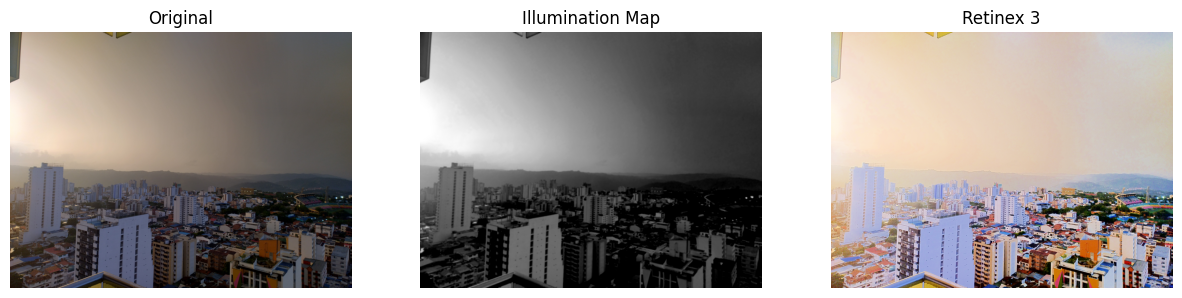

In [ ]:
vent = 15
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

T_ref3, R_3 = retinexVen(image,vent,gamma,eps)

plt.subplot(1,3,2)
plt.imshow(T_ref3, cmap='gray')
plt.title("Illumination Map")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(R_3)
plt.title("Retinex 3")
plt.axis("off")

plt.show()

# Problema de Optimizacion

Con la estimacion del mapa de iluminacion el paper propone el siguiente problema de optimizacion para mejorar el metodo:

$\min_{T,G} \;\| \hat{T} - T \|_{F}^{2} + \alpha \, \| W \circ G \|_{1}$

Con $W$ siendo la matrix de pesos y $G = \nabla T$ es la derivada de primer orden (gradiente); $α$ es un coeficiente de balance (regularizacion).

El paper usa multiplicadores de Lagrange para la solucion del problema de optimizacion, definiendo $Z$ como los multiplicadores y la tecnica ALM (Augmented Lagrangian Method) penalizando el incumplimiento de restricciones.

El mapa $T$, se actualizara de manera iterativa de la siguiente forma:

$T^{(t+1)} \leftarrow \arg\min_{T} \;
\| \hat{T} - T \|_{F}^{2} + \Phi(Z^{(t)}, \nabla T - G^{(t)})$

Definiendo la funcion lagrangiana aumentada:
$\Phi(Z, \nabla T - G) \;=\; \frac{\mu}{2} \, \| \nabla T - G \|_{F}^{2} \;+\; \langle Z, \nabla T - G \rangle$ en este contesto se expresaria $μ$ como $μ^{(t)}$ al ser un parametro de penalizacion del metodo.





Se deriva la expresion y se iguala a 0, introduciendo la matriz D de Toeplitz la cual representa las derivadas discretas por medio de "componentes" horizontal y vertical $[h,v]$.

$2 \left( T - \hat{T} \right) + \mu^{(t)} D^{T} \left( D T - G^{(t)} \right) + D^{T} Z^{(t)} = 0$

Despejando:

$\left( 2I + \mu^{(t)} D^{T} D \right) T
= 2 \hat{T} \;+\; \mu^{(t)} D^{T} \left( G^{(t)} - \frac{Z^{(t)}}{\mu^{(t)}} \right)$

Para encontrar el valor T (y asignarle ese valor a la siguiente iteracion), se requiere encontrar la inversa, por ende se utiliza la transformada de Fourier para disminuir el coste computacional (La matriz D se comporta como convolucion aplicada horizontal y verticalmente y por el teorema de la convolucion los calculos computacionales se simplifican).

$T^{(t+1)} \;\leftarrow\; \mathcal{F}^{-1} \left(
\frac{ \mathcal{F}\!\left( 2 \hat{T} \;+\; \mu^{(t)} D^{T} \big( G^{(t)} - Z^{(t)} \big) \right) }
     { 2 \;+\; \mu^{(t)} \sum_{d \in \{h,v\}} \overline{\mathcal{F}(D_{d})} \circ \mathcal{F}(D_{d}) }
\right)$

En definitiva, no se realizo la aproximacion de T por Fourier, debido a que D no fue tomada como matriz como tal (se realizo la convolucion con D siendo [-1,1]).

De manera similar se actualizan los pesos de G, utilizando $S_{A(x)}[B(x)]=sgn(B(x))max(|B(x)|-A(x),0)$ denominado Operador Shrinkage, esto ayuda a preservar bordes.


$G^{(t+1)} \;=\; \mathcal{S}_{\frac{\alpha W}{\mu^{(t)}}}
\left( \nabla T^{(t+1)} \;+\; \frac{Z^{(t)}}{\mu^{(t)}} \right)$

Finalmente Z y $\mu$ se actualizan de la siguiente manera:

$Z^{(t+1)} \;\leftarrow\; Z^{(t)} \;+\; \mu^{(t)} \big( \nabla T^{(t+1)} - G^{(t+1)} \big) \,;$

$\mu^{(t+1)} \;\leftarrow\; \mu^{(t)} \rho, \;\; \rho > 1$

Finalmente para que el algoritmo se detenga en algun punto, se acuerda un limite de iteraciones, ademas de detenerse cuando $\| \nabla T^{(t+1)} - G^{(t+1)} \|_{F} \;\leq\; \delta \, \| \hat{T} \|_{F}
$ con $\delta = 10^{-5}$ es decir si hay convergencia.

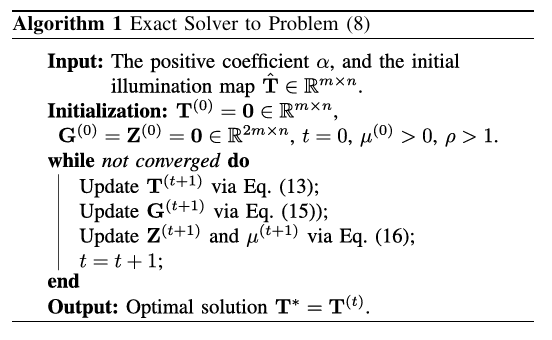

In [ ]:
def gradient_h(img):
  return np.roll(img, -1, axis=1) - img

def gradient_v(img):
  return np.roll(img, -1, axis=0) - img

def divergence_h(img):
  return img - np.roll(img, 1, axis=1)

def divergence_v(img):
  return img - np.roll(img, 1, axis=0)

def shrinkage(x, kappa):
  return np.sign(x) * np.maximum(np.abs(x) - kappa, 0)

In [ ]:
def exact_sol(img,alpha,mu,rho,gamma,eps,max_iter,delta):
  img = img.astype(np.float32) / 255.0
  T_hat = np.max(img, axis=2)
  h, w = T_hat.shape

  Wx = 1 / (np.abs(gradient_h(T_hat)) + eps)
  Wy = 1 / (np.abs(gradient_v(T_hat)) + eps)
  T = T_hat.copy()

  Gx = np.zeros_like(T)
  Gy = np.zeros_like(T)

  Zx = np.zeros_like(T)
  Zy = np.zeros_like(T)
  for i in range(max_iter):
    div = (divergence_h(Gx - Zx / mu) +divergence_v(Gy - Zy / mu))
    numerator =  2 * T_hat + mu * div
    denominator = 2 + mu * 4

    T = numerator / denominator
    Tx = gradient_h(T)
    Ty = gradient_v(T)
    Gx = shrinkage(Tx + Zx / mu,alpha * Wx / mu)
    Gy = shrinkage(Ty + Zy / mu,alpha * Wy / mu)
    Zx = Zx + mu * (Tx - Gx)
    Zy = Zy + mu * (Ty - Gy)
    mu = mu * rho
    if np.sqrt(np.sum((Tx - Gx)**2) +np.sum((Ty - Gy)**2)) <= delta*np.linalg.norm(T_hat):
        break

  T = np.clip(T, 0.3, 1)
  T = np.power(T, gamma)

  R = img / (T[:, :, np.newaxis] + eps)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T, R_uint8

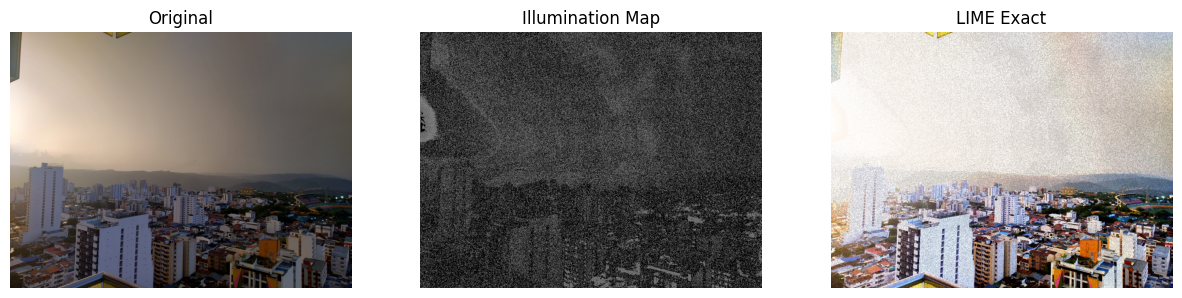

In [ ]:
alpha = 0.15
mu = 0.2
rho = 1.5
gamma = 0.8
eps = 1e-6
max_iter = 30
delta = 1e-5

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

Tex, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(1,3,2)
plt.imshow(Tex, cmap='gray')
plt.title("Illumination Map")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

plt.show()

# Aumentando Velocidad

El paper usa una aproximacion de $ ∥W \circ ∇T∥_{1}$ para reducir la complejidad algoritmica de la solucion exacta; se utilizan adicionalmente versiones vectorizadas, sin la necesidad del Operador Shrinkage.

$\min_{T} \; \| \hat{T} - T \|_{F}^{2}
+ \alpha \sum_{x} \sum_{d \in \{h,v\}}
\frac{ W_{d}(x) \, \big( \nabla_{d} T(x) \big)^{2} }
{ \left| \nabla_{d} \hat{T}(x) \right| + \epsilon }$


In [ ]:
def lime_spedup(img,alpha,gamma,eps):
  img = img.astype(np.float32) / 255.0

  T_hat = np.max(img, axis=2)

  grad_x = gradient_h(T_hat)
  grad_y = gradient_v(T_hat)

  Wx = 1.0 / (np.abs(grad_x) + eps)
  Wy = 1.0 / (np.abs(grad_y) + eps)

  denominator = (1+ alpha * (Wx * (grad_x ** 2) / (np.abs(grad_x) + eps)+Wy * (grad_y ** 2) / (np.abs(grad_y) + eps)))

  T = T_hat / denominator
  T = np.power(T, gamma)
  T = np.clip(T, 0.2, 1)

  R = img / (T[:, :, np.newaxis] + eps)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T, R_uint8

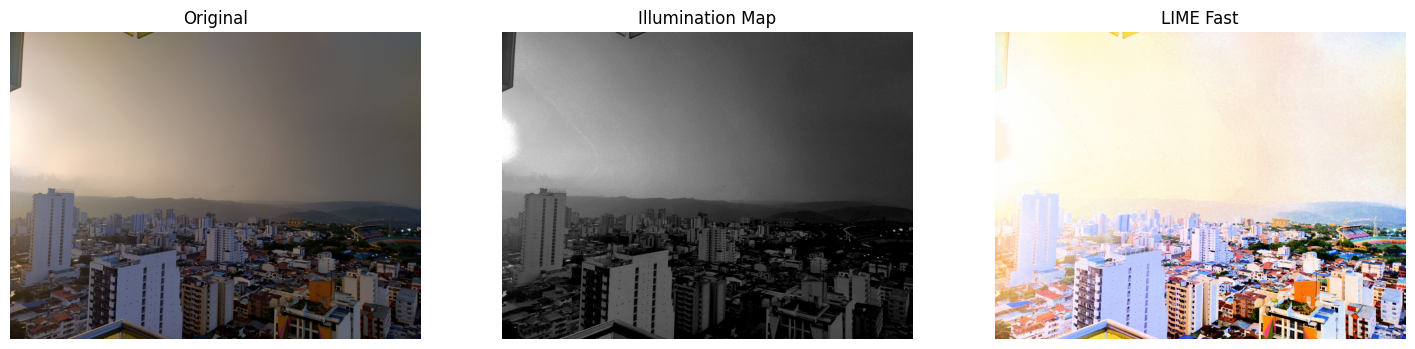

In [ ]:
alpha = 0.15
gamma = 0.8
eps = 1e-6

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

Tfa, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(1,3,2)
plt.imshow(Tfa, cmap='gray')
plt.title("Illumination Map")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

plt.show()

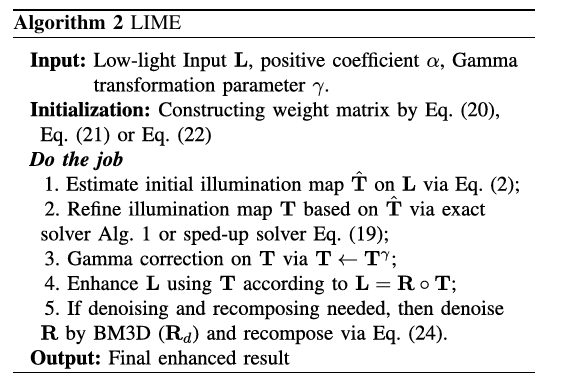

## Estrategias de Pesos W




Se establece cada componente de los pesos horizontal y vertical $d \in [h,v]$ por alguna de las siguientes estrategias:

1.   Pesos $d$ igual a $1$
2.   Pesos $d$ igual a $1/(\nabla_{d} \hat{T}(x) + ϵ)$
3.  Pesos $d$ igual a $\mathbf{W}_b(x) \leftarrow
\sum_{y \in \Omega(x)}
\frac{G_\sigma(x, y)}
{\left| \sum_{y \in \Omega(x)} G_\sigma(x, y)\, \nabla_b \hat{\mathbf{T}}(y) \right| + \epsilon}$

Siendo $G_\sigma(x, y)$ un kernel gausiano que se comporta como una distribucion exponencial $\exp\left(-\frac{\operatorname{dist}(x,y)}{2\sigma^{2}}\right)$

Finalmente tras obtener $T$, se le puede realizar una correccion ganma (el paper recomienda 0.8), para finalmente obtener $R$.

In [ ]:
def w_stratIII(T,sigma,eps):
  Gx = gradient_h(T)
  Gy = gradient_v(T)
  mag_h = ndimage.gaussian_filter(np.abs(Gx), sigma=sigma)
  mag_v = ndimage.gaussian_filter(np.abs(Gy), sigma=sigma)
  Wx = 1.0 / (mag_h + eps)
  Wy = 1.0 / (mag_v + eps)
  return Wx, Wy

In [ ]:
def lime_wIII(img,alpha,gamma,sigma,eps):
  img = img.astype(np.float32) / 255.0

  T_hat = np.max(img, axis=2)

  grad_x = gradient_h(T_hat)
  grad_y = gradient_v(T_hat)

  Wx, Wy = w_stratIII(T_hat,sigma,eps)

  denominator = (1+ alpha * (Wx * (grad_x ** 2) / (np.abs(grad_x) + eps)+Wy * (grad_y ** 2) / (np.abs(grad_y) + eps)))

  T = T_hat / denominator
  T = np.power(T, gamma)
  T = np.clip(T, 0.2, 1)

  R = img / (T[:, :, np.newaxis] + eps)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T, R_uint8

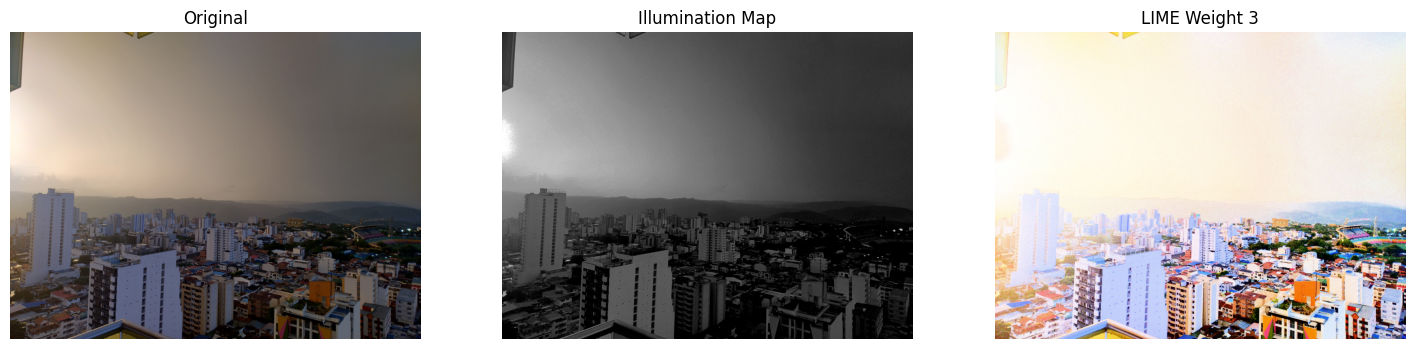

In [ ]:
alpha = 0.15
gamma = 0.8
sigma = 3
eps = 1e-6

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

Tw3, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(1,3,2)
plt.imshow(Tw3, cmap='gray')
plt.title("Illumination Map")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

plt.show()

## Otras Imagenes

In [ ]:
a = 0.95
vent = 15
alpha = 0.15
mu = 0.2
rho = 1.5
gamma = 0.8
eps = 1e-6
sigma = 3
max_iter = 30
delta = 1e-5

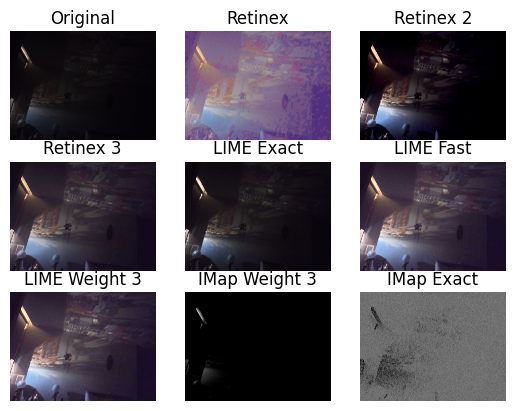

In [ ]:
image = cv.imread('/content/sample_data/1000380747.jpg')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(3,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(3,3,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(3,3,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(3,3,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

Tex, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(3,3,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(3,3,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

Tw3, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(3,3,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

plt.subplot(3,3,8)
plt.imshow(Tw3, cmap='gray')
plt.title("IMap Weight 3")
plt.axis("off")

plt.subplot(3,3,9)
plt.imshow(Tex, cmap='gray')
plt.title("IMap Exact")
plt.axis("off")

plt.show()

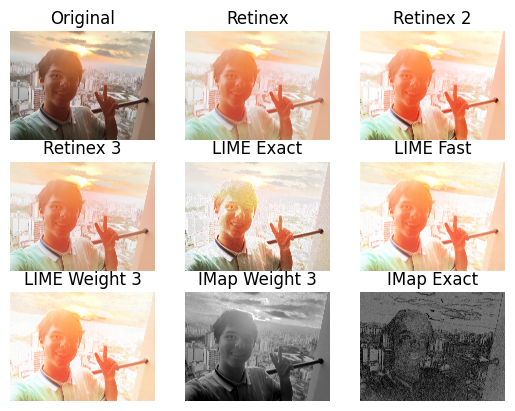

In [ ]:
image = cv.imread('/content/sample_data/1000333635.jpg')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(3,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(3,3,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(3,3,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(3,3,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

Tex, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(3,3,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(3,3,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

Tw3, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(3,3,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

plt.subplot(3,3,8)
plt.imshow(Tw3, cmap='gray')
plt.title("IMap Weight 3")
plt.axis("off")

plt.subplot(3,3,9)
plt.imshow(Tex, cmap='gray')
plt.title("IMap Exact")
plt.axis("off")

plt.show()

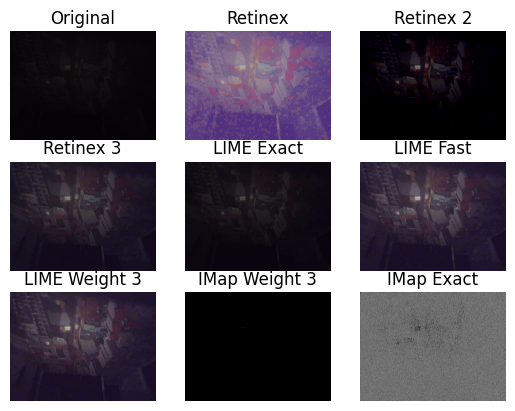

In [ ]:
image = cv.imread('/content/sample_data/1000380749.jpg')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(3,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(3,3,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(3,3,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(3,3,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

Tex, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(3,3,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(3,3,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

Tw3, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(3,3,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

plt.subplot(3,3,8)
plt.imshow(Tw3, cmap='gray')
plt.title("IMap Weight 3")
plt.axis("off")

plt.subplot(3,3,9)
plt.imshow(Tex, cmap='gray')
plt.title("IMap Exact")
plt.axis("off")

plt.show()

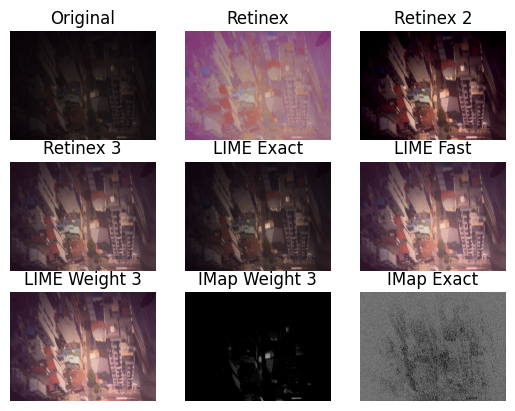

In [ ]:
image = cv.imread('/content/sample_data/1000380762.jpg')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(3,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(3,3,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(3,3,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(3,3,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

Tex, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(3,3,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(3,3,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

Tw3, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(3,3,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

plt.subplot(3,3,8)
plt.imshow(Tw3, cmap='gray')
plt.title("IMap Weight 3")
plt.axis("off")

plt.subplot(3,3,9)
plt.imshow(Tex, cmap='gray')
plt.title("IMap Exact")
plt.axis("off")

plt.show()